In [ ]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Circle, Wedge
from matplotlib.collections import PatchCollection

# import glasbey

In [ ]:
# Load the data from the files
scores_path = 'data/scores_myeloid_dmg_mp_FINAL.txt'
umap_path = 'data/quadrants_log_FINAL.txt'

scores_df = pd.read_csv(scores_path, sep='\t')
umap_df = pd.read_csv(umap_path, sep='\t')

# Display the first few rows of each dataframe for inspection
scores_df_head = scores_df.head()
umap_df_head = umap_df.head()

scores_df_head, umap_df_head

(                                  MP2       MP5       MP6       MP7       MP8  \
 BT042_PD_TGCGATAAGCCATCCG-1  0.034152 -0.006546 -0.093560  0.064429  0.114909   
 BT042_PD_GAATAGAGTTTATGCG-1  0.186855 -0.044247 -0.190026 -0.073085  0.260973   
 BT042_PD_CCTGCATAGGTCACAG-1 -0.458207 -0.000110 -0.012647  0.115024  0.165746   
 BT042_PD_CGGAGAACAACTGCTA-1 -0.154446 -0.027166 -0.155796  0.010895  0.384569   
 BT042_PD_AGGGCTCCAACTCGTA-1 -0.267972 -0.028506 -0.149260 -0.028994  0.170351   
 
                                   MP9      MP12  
 BT042_PD_TGCGATAAGCCATCCG-1 -0.072766  0.074521  
 BT042_PD_GAATAGAGTTTATGCG-1 -0.085841  0.092589  
 BT042_PD_CCTGCATAGGTCACAG-1  0.105210  0.214181  
 BT042_PD_CGGAGAACAACTGCTA-1 -0.042155  0.025644  
 BT042_PD_AGGGCTCCAACTCGTA-1 -0.073958  0.229345  ,
                              x_log_difference  y_log_difference
 BT042_PD_TGCGATAAGCCATCCG-1          0.421379         -0.163040
 BT042_PD_GAATAGAGTTTATGCG-1          0.414471         -0.439523
 BT0

In [ ]:
import numpy as np

# Process the scores dataframe
# Identify cells with at least one positive score and their top 3 signatures
scores_df_processed = scores_df.apply(lambda x: x[x > 0].nlargest(3), axis=1)
scores_df_processed['sum_positive_scores'] = scores_df_processed.sum(axis=1)
scores_df_processed['is_unresolved'] = scores_df_processed['sum_positive_scores'] <= 0

# Normalize the top 3 scores for each cell
for col in scores_df_processed.columns[:-2]:  # excluding the last two columns we added
    scores_df_processed[col] = scores_df_processed[col] / scores_df_processed['sum_positive_scores']

# Merge UMAP coordinates with the processed scores
umap_scores_df = umap_df.join(scores_df_processed, how='left')

# Replace NaN with 0 for the pie chart representation
umap_scores_df.fillna(0, inplace=True)

# Display the first few rows of the merged dataframe
umap_scores_df.head()

,x_log_difference,y_log_difference,MP12,MP2,MP5,MP6,MP7,MP8,MP9,sum_positive_scores,is_unresolved
BT042_PD_TGCGATAAGCCATCCG-1,0.421379,-0.163040,0.293554,0.000000,0.0,0.0,0.253797,0.452648,0.0,0.253859,False
BT042_PD_GAATAGAGTTTATGCG-1,0.414471,-0.439523,0.171328,0.345762,0.0,0.0,0.000000,0.482910,0.0,0.540416,False
BT042_PD_CCTGCATAGGTCACAG-1,0.191104,0.159294,0.432731,0.000000,0.0,0.0,0.232394,0.334874,0.0,0.494951,False
BT042_PD_CGGAGAACAACTGCTA-1,-0.225210,-0.164204,0.060896,0.000000,0.0,0.0,0.025872,0.913233,0.0,0.421108,False
BT042_PD_AGGGCTCCAACTCGTA-1,0.236164,0.001998,0.573800,0.000000,0.0,0.0,0.000000,0.426200,0.0,0.399696,False


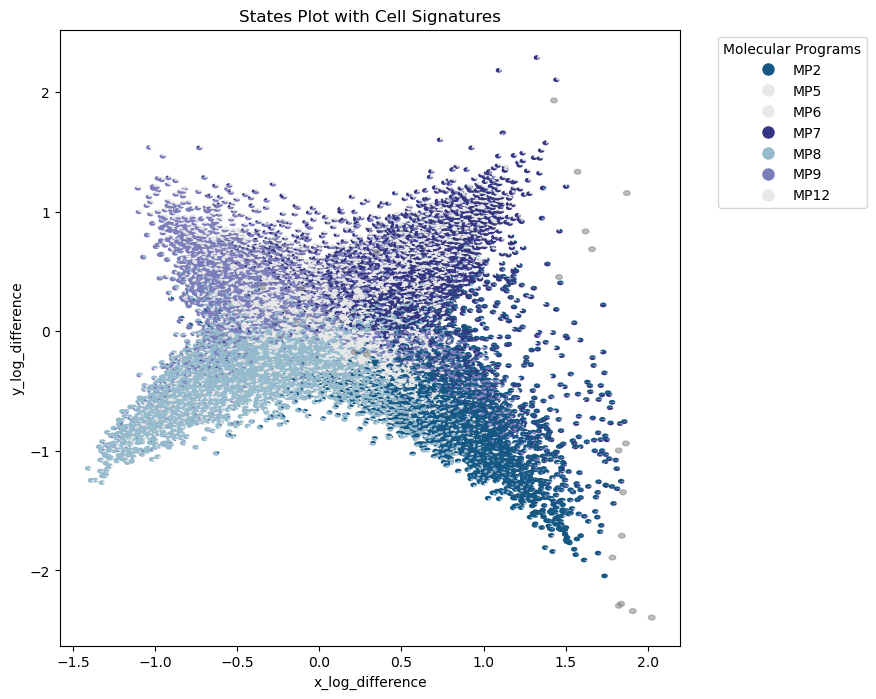

In [ ]:
colors = ['#165884','#e8e8e8','#e8e8e8', '#343682', '#95bbcd','#7b7dba','#e8e8e8'] 

# Adjust the add_pie_to_plot function to handle color indexing
def add_pie_to_plot(ax, xy, sizes, colors):
    """Add a pie chart at a given location in the plot."""
    x, y = xy
    radius = 0.02  # Size of the pie chart
    wedges = []
    cum_size = 0

    for i, size in enumerate(sizes):
        if size > 0:
            start_angle = cum_size * 360
            end_angle = (cum_size + size) * 360
            color_index = i % len(colors)  # Cycle through colors if not enough
            wedge = Wedge(center=(x, y), r=radius, theta1=start_angle, theta2=end_angle, facecolor=colors[color_index])
            wedges.append(wedge)
            cum_size += size
    
    if wedges:
        p = PatchCollection(wedges, match_original=True)
        ax.add_collection(p)
    else:  # For unresolved cells
        circle = Circle((x, y), radius, color='gray', alpha=0.5)
        ax.add_patch(circle)

# Re-plot with adjusted color assignment
fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(x='x_log_difference', y='y_log_difference', data=umap_scores_df, alpha=0, ax=ax)

# Add pie charts to the plot
for index, row in umap_scores_df.iterrows():
    sizes = row[scores_df.columns].values  # The scores are used as sizes for the pie slices
    add_pie_to_plot(ax, (row['x_log_difference'], row['y_log_difference']), sizes, colors)

# Plot customization
ax.set_title('States Plot with Cell Signatures')
ax.set_xlabel('x_log_difference')
ax.set_ylabel('y_log_difference')

# # Create a custom legend
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label=col, 
                              markersize=10, markerfacecolor=color) for col, color in zip(scores_df.columns, colors)]
ax.legend(handles=legend_elements, title="Molecular Programs", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.savefig('figures/state_plot_myeloid_FINAL.png',transparent=True,dpi=300)
plt.savefig('figures/state_plot_myeloid_FINAL.pdf')